#### Tech Challenge — Previsão de Obesidade
##### Notebook 03 — Treino, Comparação e Avaliação de Modelos

**Objetivo:** treinar, comparar e avaliar 6 modelos (3 algoritmos × 2 variantes) e persistir o melhor.

---
#### 1. Setup

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_theme(style='whitegrid', context='notebook')

# Toda a lógica vem de src/
from src.utils.config import (
    RANDOM_STATE, CLASS_ORDER, CRITICAL_CLASSES, CV_FOLDS,
    N_ITER_RANDOM_SEARCH, ARTIFACTS_DIR, TARGET_ENCODER_FILENAME,
)
from src.models import (
    load_splits, cross_validate_model, tune_xgboost, fit_full_pipeline,
    evaluate_on_test, get_confusion_matrix, get_classification_report_df,
    get_xgboost_feature_importance, plot_confusion_matrix, plot_feature_importance,
    save_best_model, save_metrics_table, save_metrics_detailed,
    ESTIMATOR_FACTORIES,
)

print(f'RANDOM_STATE = {RANDOM_STATE}  |  CV_FOLDS = {CV_FOLDS}  |  n_iter = {N_ITER_RANDOM_SEARCH}')

RANDOM_STATE = 42  |  CV_FOLDS = 5  |  n_iter = 50


---
##### 2. Carregamento dos artefatos persistidos (NB02)

Carregamos splits e target encoder gerados no notebook 02. Não recriamos preprocessing, as pipelines são construídas internamente pelas funções de `src/models/train.py`.

In [4]:
# Splits persistidos
splits = load_splits()
X_train, X_val, X_test = splits['X_train'], splits['X_val'], splits['X_test']

# Target encoder persistido
target_encoder = joblib.load(ARTIFACTS_DIR / TARGET_ENCODER_FILENAME)

# Encoda os targets (inteiros ordinais em ordem clínica)
y_train = target_encoder.transform(splits['y_train'])
y_val   = target_encoder.transform(splits['y_val'])
y_test  = target_encoder.transform(splits['y_test'])

print(f'Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}')
print(f'Classes (ordem clínica): {list(target_encoder.classes_)}')

Train: (1460, 16)  |  Val: (313, 16)  |  Test: (314, 16)
Classes (ordem clínica): [np.str_('Insufficient_Weight'), np.str_('Normal_Weight'), np.str_('Overweight_Level_I'), np.str_('Overweight_Level_II'), np.str_('Obesity_Type_I'), np.str_('Obesity_Type_II'), np.str_('Obesity_Type_III')]


---
##### 3. Validação cruzada — 6 modelos

Rodamos `cross_validate_model` para cada combinação (algoritmo × variante). Cada chamada:
- constrói a pipeline apropriada (LogReg recebe scaling; árvores não)
- roda StratifiedKFold cv=5 no treino
- retorna F1-macro e accuracy médios +/- desvio

In [5]:
cv_rows = []
for variant in ['A', 'B']:
    for model_name in ESTIMATOR_FACTORIES:
        result = cross_validate_model(model_name, variant, X_train, y_train)
        cv_rows.append(result)
        print(f"  {model_name:20s} [{variant}]  "
              f"F1-macro = {result['f1_macro_mean']:.4f} ± {result['f1_macro_std']:.4f}  "
              f"|  Acc = {result['accuracy_mean']:.4f} ± {result['accuracy_std']:.4f}")

cv_df = pd.DataFrame(cv_rows)

  LogisticRegression   [A]  F1-macro = 0.8959 ± 0.0156  |  Acc = 0.9000 ± 0.0148
  RandomForest         [A]  F1-macro = 0.9851 ± 0.0051  |  Acc = 0.9856 ± 0.0050
  XGBoost              [A]  F1-macro = 0.9747 ± 0.0093  |  Acc = 0.9753 ± 0.0085
  LogisticRegression   [B]  F1-macro = 0.5443 ± 0.0305  |  Acc = 0.5733 ± 0.0251
  RandomForest         [B]  F1-macro = 0.8292 ± 0.0281  |  Acc = 0.8356 ± 0.0270
  XGBoost              [B]  F1-macro = 0.8141 ± 0.0110  |  Acc = 0.8212 ± 0.0111


In [6]:
# Tabela consolidada, ordenada por F1-macro
cv_table = (
    cv_df
    .sort_values('f1_macro_mean', ascending=False)
    .reset_index(drop=True)
    .round(4)
)
cv_table

,model,variant,f1_macro_mean,f1_macro_std,accuracy_mean,accuracy_std
0,RandomForest,A,0.9851,0.0051,0.9856,0.0050
1,XGBoost,A,0.9747,0.0093,0.9753,0.0085
2,LogisticRegression,A,0.8959,0.0156,0.9000,0.0148
3,RandomForest,B,0.8292,0.0281,0.8356,0.0270
4,XGBoost,B,0.8141,0.0110,0.8212,0.0111
5,LogisticRegression,B,0.5443,0.0305,0.5733,0.0251


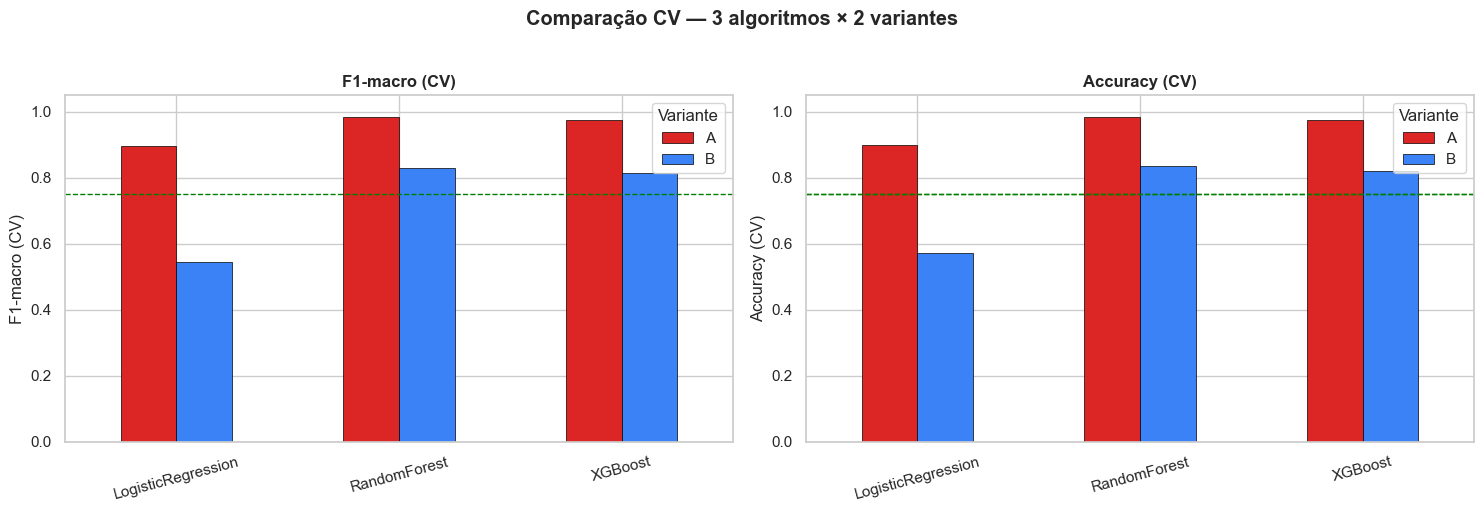

In [7]:
# Visualização comparativa: F1-macro por modelo e variante
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metric, label in zip(
    axes,
    ['f1_macro_mean', 'accuracy_mean'],
    ['F1-macro (CV)', 'Accuracy (CV)']
):
    pivot = cv_df.pivot(index='model', columns='variant', values=metric)
    pivot.plot(kind='bar', ax=ax, color=['#dc2626', '#3b82f6'],
               edgecolor='black', linewidth=0.5)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Variante')
    ax.axhline(0.75, color='green', linestyle='--', linewidth=1,
               label='requisito 75%' if metric == 'accuracy_mean' else None)
    ax.set_ylim(0, 1.05)

axes[1].axhline(0.75, color='green', linestyle='--', linewidth=1)
plt.suptitle('Comparação CV — 3 algoritmos × 2 variantes', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
##### 4. Tuning do XGBoost

Apenas o XGBoost recebe tuning

Tunei as duas variantes (A e B) separadamente.

In [8]:
# Tuning XGBoost — Modelo A
print('Tuning XGBoost Modelo A...')
best_xgb_a, info_a = tune_xgboost('A', X_train, y_train, n_iter=N_ITER_RANDOM_SEARCH)
print(f"  Melhor F1-macro (CV): {info_a['best_cv_f1_macro']:.4f}")
print(f"  Melhores hiperparâmetros:")
for k, v in info_a['best_params'].items():
    print(f"    {k.replace('model__', '')}: {v}")

Tuning XGBoost Modelo A...
  Melhor F1-macro (CV): 0.9788
  Melhores hiperparâmetros:
    subsample: 0.8
    reg_lambda: 0.1
    reg_alpha: 0
    n_estimators: 300
    min_child_weight: 1
    max_depth: 6
    learning_rate: 0.01
    colsample_bytree: 0.7


In [9]:
# Tuning XGBoost — Modelo B
print('Tuning XGBoost Modelo B...')
best_xgb_b, info_b = tune_xgboost('B', X_train, y_train, n_iter=N_ITER_RANDOM_SEARCH)
print(f"  Melhor F1-macro (CV): {info_b['best_cv_f1_macro']:.4f}")
print(f"  Melhores hiperparâmetros:")
for k, v in info_b['best_params'].items():
    print(f"    {k.replace('model__', '')}: {v}")

Tuning XGBoost Modelo B...
  Melhor F1-macro (CV): 0.8211
  Melhores hiperparâmetros:
    subsample: 0.8
    reg_lambda: 1.0
    reg_alpha: 0.5
    n_estimators: 100
    min_child_weight: 1
    max_depth: 6
    learning_rate: 0.1
    colsample_bytree: 1.0


---
##### 5. Avaliação final no conjunto de teste

Agora usamos o conjunto de teste, mantido isolado no notebook 02. Avaliamos os XGBoost tunados (A e B) mais os baselines (LogReg, RF).

Métricas: F1-macro, accuracy e recall das classes clínicas críticas (Obesity_Type_II e III).

In [10]:
# Treina os baselines no full train para avaliação final
fitted_models = {
    ('XGBoost', 'A'): best_xgb_a,
    ('XGBoost', 'B'): best_xgb_b,
}
for variant in ['A', 'B']:
    for model_name in ['LogisticRegression', 'RandomForest']:
        fitted_models[(model_name, variant)] = fit_full_pipeline(
            model_name, variant, X_train, y_train
        )
print(f'Modelos treinados para avaliação final: {len(fitted_models)}')

Modelos treinados para avaliação final: 6


In [11]:
# Avalia todos no teste
test_rows = []
detailed_recall = {}
for (model_name, variant), pipeline in fitted_models.items():
    res = evaluate_on_test(pipeline, X_test, y_test, target_encoder, model_name, variant)
    detailed_recall[f'{model_name}_{variant}'] = res.pop('recall_by_class')
    test_rows.append(res)

test_df = pd.DataFrame(test_rows).sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
test_df.round(4)

,model,variant,test_f1_macro,test_accuracy,recall_Obesity_Type_II,recall_Obesity_Type_III
0,RandomForest,A,1.0000,1.0000,1.0000,1.0
1,XGBoost,A,0.9700,0.9713,1.0000,1.0
2,LogisticRegression,A,0.9093,0.9140,1.0000,1.0
3,XGBoost,B,0.8261,0.8344,0.9778,1.0
4,RandomForest,B,0.8083,0.8185,0.9778,1.0
5,LogisticRegression,B,0.5459,0.5796,0.8222,1.0


In [12]:
# Verificação do requisito do challenge (accuracy > 75%)
print('Verificação do requisito do challenge (accuracy > 75%):')
print('-' * 55)
for _, row in test_df.iterrows():
    status = '✓ PASSA' if row['test_accuracy'] > 0.75 else '✗ abaixo'
    print(f"  {row['model']:20s} [{row['variant']}]  "
          f"Acc = {row['test_accuracy']:.4f}  {status}")

Verificação do requisito do challenge (accuracy > 75%):
-------------------------------------------------------
  RandomForest         [A]  Acc = 1.0000  ✓ PASSA
  XGBoost              [A]  Acc = 0.9713  ✓ PASSA
  LogisticRegression   [A]  Acc = 0.9140  ✓ PASSA
  XGBoost              [B]  Acc = 0.8344  ✓ PASSA
  RandomForest         [B]  Acc = 0.8185  ✓ PASSA
  LogisticRegression   [B]  Acc = 0.5796  ✗ abaixo


---
#### 6. Seleção do modelo final

 Persistimos **dois** artefatos:
- O melhor Modelo A (diagnóstico/baseline de sanidade)
- O melhor Modelo B (triagem comportamental, o que vai para o app como destaque)

In [13]:
# Melhor A e melhor B por F1-macro no teste
best_a_row = test_df[test_df['variant'] == 'A'].iloc[0]
best_b_row = test_df[test_df['variant'] == 'B'].iloc[0]

print('Melhor Modelo A (diagnóstico):')
print(f"  {best_a_row['model']}  |  F1={best_a_row['test_f1_macro']:.4f}  Acc={best_a_row['test_accuracy']:.4f}")
print()
print('Melhor Modelo B (triagem comportamental):')
print(f"  {best_b_row['model']}  |  F1={best_b_row['test_f1_macro']:.4f}  Acc={best_b_row['test_accuracy']:.4f}")

best_a_pipeline = fitted_models[(best_a_row['model'], 'A')]
best_b_pipeline = fitted_models[(best_b_row['model'], 'B')]

Melhor Modelo A (diagnóstico):
  RandomForest  |  F1=1.0000  Acc=1.0000

Melhor Modelo B (triagem comportamental):
  XGBoost  |  F1=0.8261  Acc=0.8344


---
##### 7. Matrizes de confusão

Para os dois modelos selecionados. A matriz revela onde o modelo confunde classes adjacentes, particularmente importante para distinguir níveis de sobrepeso e obesidade.

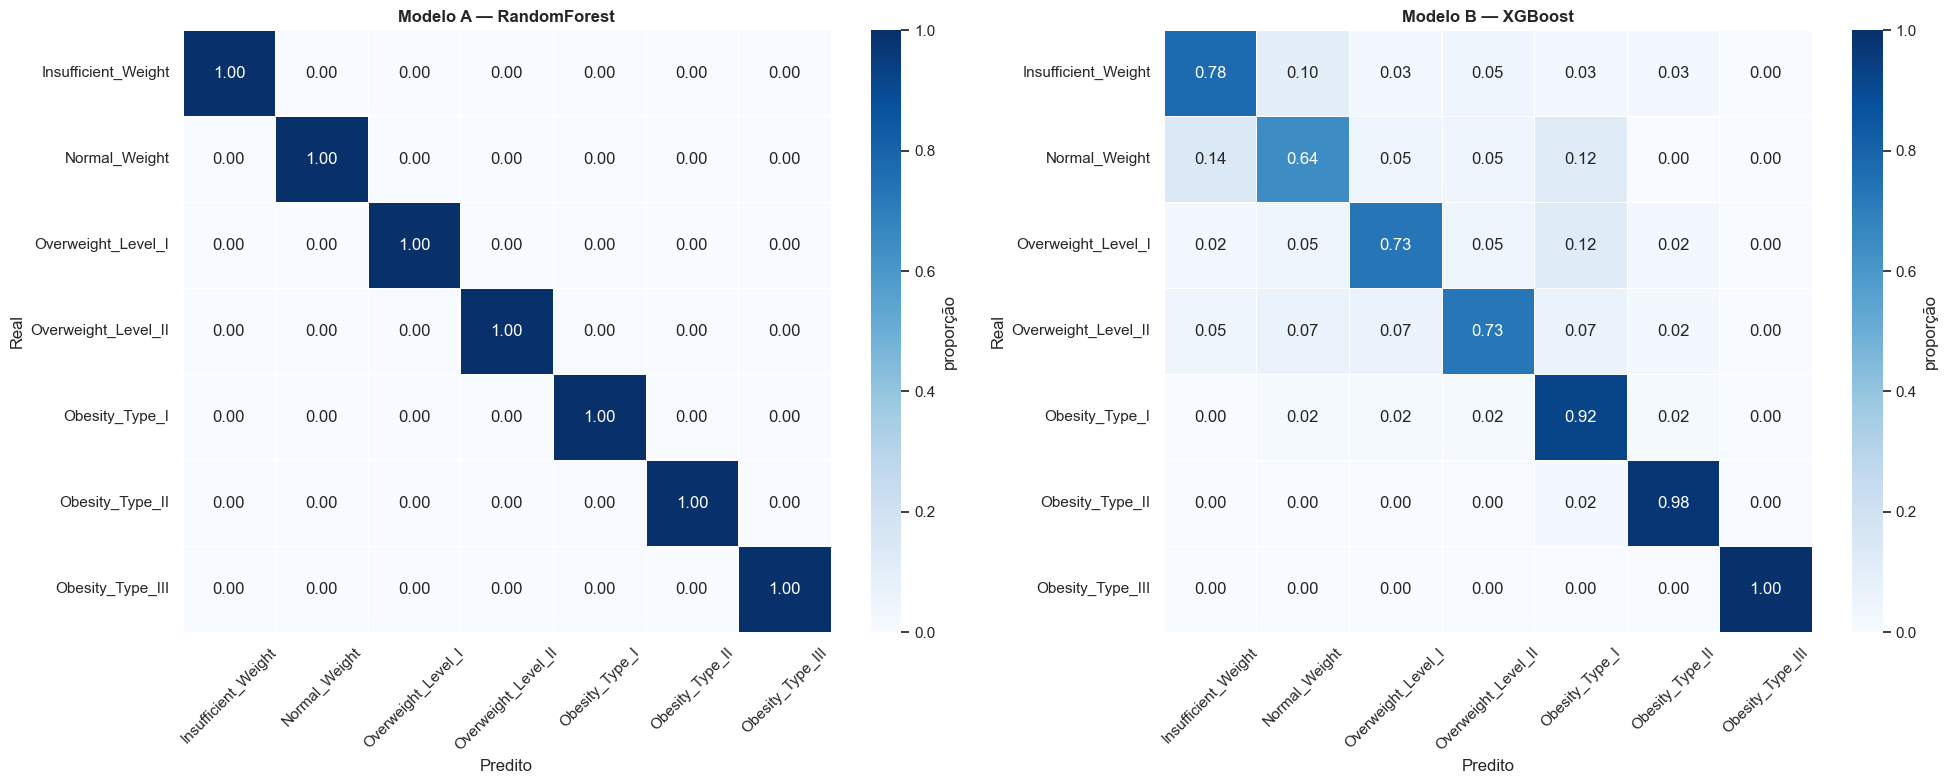

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

cm_a = get_confusion_matrix(best_a_pipeline, X_test, y_test)
plot_confusion_matrix(cm_a, title=f"Modelo A — {best_a_row['model']}",
                      normalize=True, ax=axes[0])

cm_b = get_confusion_matrix(best_b_pipeline, X_test, y_test)
plot_confusion_matrix(cm_b, title=f"Modelo B — {best_b_row['model']}",
                      normalize=True, ax=axes[1])

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

**Como ler:** valores na diagonal = acertos (normalizados por linha = recall por classe). Fora da diagonal = confusões. Espera-se que o Modelo B confunda mais classes adjacentes (ex: Overweight_I ↔ Overweight_II), já que não tem acesso ao peso.

---
## 8. Classification report por classe

In [15]:
print('=== Modelo A (diagnóstico) ===')
report_a = get_classification_report_df(best_a_pipeline, X_test, y_test)
display(report_a.round(3))

=== Modelo A (diagnóstico) ===


,precision,recall,f1-score,support
Insufficient_Weight,1.0,1.0,1.0,40.0
Normal_Weight,1.0,1.0,1.0,42.0
Overweight_Level_I,1.0,1.0,1.0,41.0
Overweight_Level_II,1.0,1.0,1.0,44.0
Obesity_Type_I,1.0,1.0,1.0,53.0
Obesity_Type_II,1.0,1.0,1.0,45.0
Obesity_Type_III,1.0,1.0,1.0,49.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,314.0
weighted avg,1.0,1.0,1.0,314.0


In [16]:
print('=== Modelo B (triagem comportamental) ===')
report_b = get_classification_report_df(best_b_pipeline, X_test, y_test)
display(report_b.round(3))

=== Modelo B (triagem comportamental) ===


,precision,recall,f1-score,support
Insufficient_Weight,0.775,0.775,0.775,40.000
Normal_Weight,0.730,0.643,0.684,42.000
Overweight_Level_I,0.811,0.732,0.769,41.000
Overweight_Level_II,0.821,0.727,0.771,44.000
Obesity_Type_I,0.766,0.925,0.838,53.000
Obesity_Type_II,0.917,0.978,0.946,45.000
Obesity_Type_III,1.000,1.000,1.000,49.000
accuracy,0.834,0.834,0.834,0.834
macro avg,0.831,0.826,0.826,314.000
weighted avg,0.834,0.834,0.832,314.000


---
##### 9. Recall nas classes clínicas críticas

`Obesity_Type_II` e `Obesity_Type_III` são as classes onde um falso negativo é maior, deixar de identificar obesidade severa tem maior custo clínico. Comparamos o recall dessas classes entre os modelos.

Recall nas classes críticas:


,model,variant,Obesity_Type_II,Obesity_Type_III
0,RandomForest,A,1.0000,1.0
1,XGBoost,A,1.0000,1.0
2,LogisticRegression,A,1.0000,1.0
3,XGBoost,B,0.9778,1.0
4,RandomForest,B,0.9778,1.0
5,LogisticRegression,B,0.8222,1.0


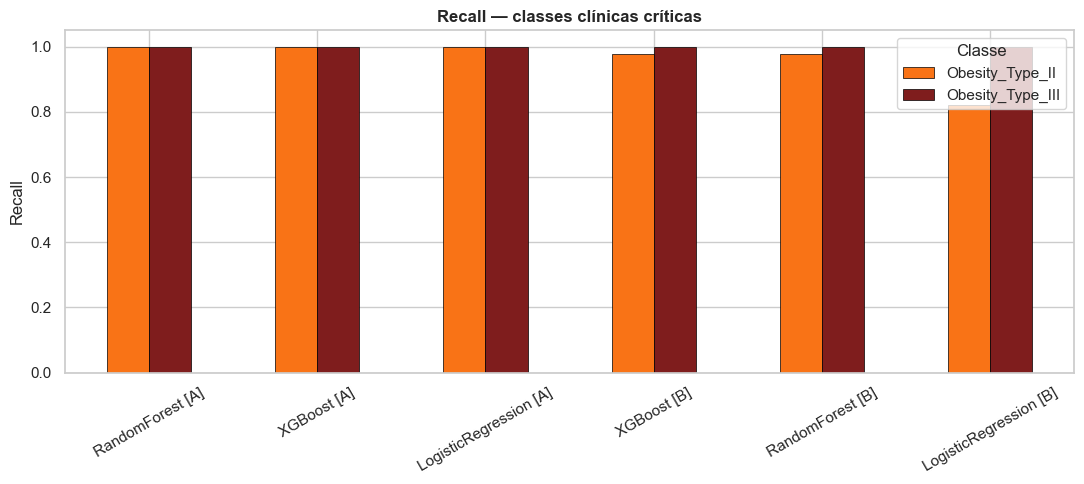

In [17]:
critical_cols = ['model', 'variant'] + [f'recall_{c}' for c in CRITICAL_CLASSES]
critical_df = test_df[critical_cols].copy()
critical_df.columns = ['model', 'variant'] + CRITICAL_CLASSES
print('Recall nas classes críticas:')
display(critical_df.round(4))

# Visualização
fig, ax = plt.subplots(figsize=(11, 5))
plot_data = critical_df.set_index(critical_df['model'] + ' [' + critical_df['variant'] + ']')[CRITICAL_CLASSES]
plot_data.plot(kind='bar', ax=ax, color=['#f97316', '#7f1d1d'],
               edgecolor='black', linewidth=0.5)
ax.set_title('Recall — classes clínicas críticas', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Recall')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Classe')
plt.tight_layout()
plt.show()

---
#### 10. Feature importance — XGBoost

Importância das variáveis nos dois modelos XGBoost. No Modelo A, esperamos Weight/IMC dominando (confirmando o leakage estrutural). No Modelo B, vemos quais variáveis comportamentais carregam o sinal, esse é o insight clínico real.

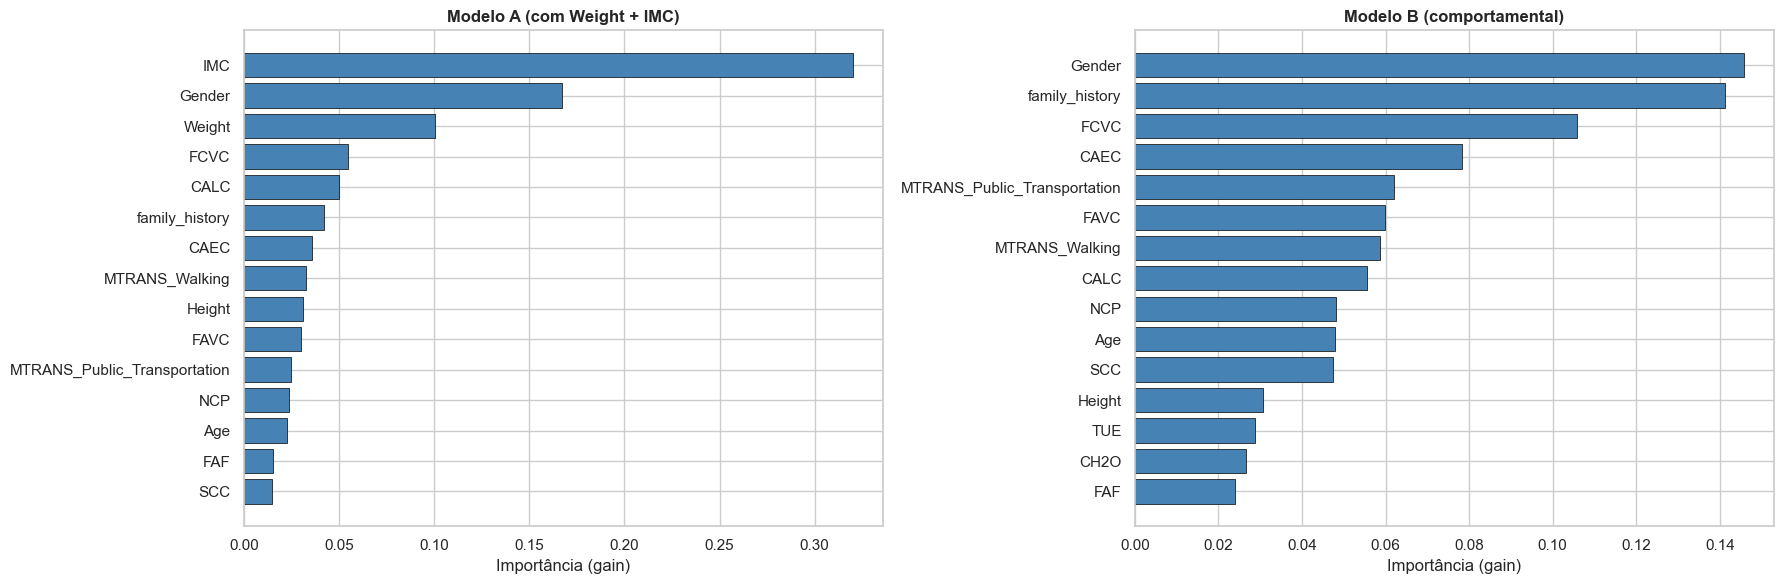

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

fi_a = get_xgboost_feature_importance(best_xgb_a)
plot_feature_importance(fi_a, top_n=15,
                        title='Modelo A (com Weight + IMC)', ax=axes[0])

fi_b = get_xgboost_feature_importance(best_xgb_b)
plot_feature_importance(fi_b, top_n=15,
                        title='Modelo B (comportamental)', ax=axes[1])

plt.tight_layout()
plt.show()

In [19]:
print('Top 10 features — Modelo B (comportamental, valor clínico):')
display(fi_b.head(10).round(4))

Top 10 features — Modelo B (comportamental, valor clínico):


,feature,importance
0,Gender,0.1457
1,family_history,0.1413
2,FCVC,0.1057
3,CAEC,0.0784
4,MTRANS_Public_Transportation,0.0620
5,FAVC,0.0598
6,MTRANS_Walking,0.0586
7,CALC,0.0556
8,NCP,0.0481
9,Age,0.0480


Insight clínico: as features mais importantes do Modelo B indicam quais fatores comportamentais e demográficos mais ajudam a prever obesidade na ausência do peso. Esses são os "alvos de intervenção" que a equipe médica pode acionar preventivamente.

---
##### 11. Persistência dos modelos e métricas

Salvamos:
- **`best_pipeline.joblib`** — o melhor Modelo B (triagem comportamental, destaque do app)
- **`pipeline_model_a.joblib`** — o melhor Modelo A (diagnóstico/baseline)
- **`metrics_comparison.csv`** — tabela consolidada CV + teste
- **`metrics_detailed.json`** — recall por classe, best_params do tuning

In [20]:
from src.utils.config import PIPELINE_MODEL_A_FILENAME, BEST_MODEL_FILENAME

# Modelo B é o destaque (best_pipeline.joblib)
path_b = save_best_model(best_b_pipeline, filename=BEST_MODEL_FILENAME)
print(f'✓ Modelo B (triagem) salvo: {path_b.relative_to(PROJECT_ROOT)}')

# Modelo A como artefato secundário
path_a = save_best_model(best_a_pipeline, filename=PIPELINE_MODEL_A_FILENAME)
print(f'✓ Modelo A (diagnóstico) salvo: {path_a.relative_to(PROJECT_ROOT)}')

✓ Modelo B (triagem) salvo: models\artifacts\best_pipeline.joblib
✓ Modelo A (diagnóstico) salvo: models\artifacts\pipeline_model_a.joblib


In [21]:
# Métricas consolidadas: CV + teste num único CSV
cv_df['stage'] = 'cv'
test_export = test_df.copy()
test_export['stage'] = 'test'
metrics_consolidated = pd.concat([
    cv_df.rename(columns={'f1_macro_mean': 'f1_macro', 'accuracy_mean': 'accuracy'})[
        ['stage', 'model', 'variant', 'f1_macro', 'accuracy']
    ],
    test_export.rename(columns={'test_f1_macro': 'f1_macro', 'test_accuracy': 'accuracy'})[
        ['stage', 'model', 'variant', 'f1_macro', 'accuracy']
    ],
], ignore_index=True)

path_csv = save_metrics_table(metrics_consolidated)
print(f'✓ Métricas consolidadas: {path_csv.relative_to(PROJECT_ROOT)}')

# Detalhado em JSON
detailed = {
    'best_model_a': {'model': best_a_row['model'],
                     'test_f1_macro': float(best_a_row['test_f1_macro']),
                     'test_accuracy': float(best_a_row['test_accuracy'])},
    'best_model_b': {'model': best_b_row['model'],
                     'test_f1_macro': float(best_b_row['test_f1_macro']),
                     'test_accuracy': float(best_b_row['test_accuracy'])},
    'xgb_tuning_a': info_a,
    'xgb_tuning_b': info_b,
    'recall_by_class': detailed_recall,
}
path_json = save_metrics_detailed(detailed)
print(f'✓ Métricas detalhadas: {path_json.relative_to(PROJECT_ROOT)}')

✓ Métricas consolidadas: models\artifacts\metrics_comparison.csv
✓ Métricas detalhadas: models\artifacts\metrics_detailed.json
